In [31]:
%pylab inline

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [9]:
from pycbc.events.hm_utils import number_coincident_combinations, get_coincident_window

In [27]:
def N_comb(tlen, M, N):
    out = (tlen - M) * (2*N + 1) * (2*M + 1) + 4 + (13 * N) / 3 
    out += 4 * N**2 - (N**3) / 3 + M**2 * (2 + 6 * N) 
    out += M * (6 + 11 * N - N**2)
    return out

def N_comb2(tlen):
    out =  595 * tlen + 4969
    return out

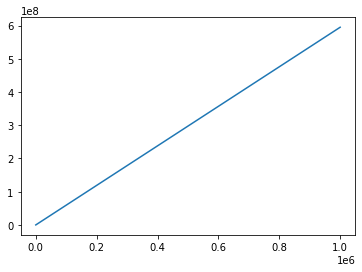

In [33]:
x = linspace(1, 1e6, int(1e6))
y = N_comb2(x)
plot(x, y)

In [37]:
N_comb2(5000) / N_comb2(5000)

1.0

In [28]:
tlen = 5000
M = 17
N = 8
N_comb(tlen, M, N), N_comb2(tlen)

(2979969.0, 2979969)

In [21]:
17 * 35

595

When \(N = 8\) and \(M = 17\), the value of $N_{tail}$ is 15084.

In [8]:
N_comb(5000, 13, 8), number_coincident_combinations(5000, 13, 8), 5000**3/number_coincident_combinations(5000, 13, 8)

(2297997.0, 2296090, 54440.3747239873)

In [10]:
ifos = ["H1", "L1", "V1"]

In [16]:
t2_coinc_window, t3_coinc_window, segment_overlap, alpha_23, \
    t23_coinc_window = get_coincident_window(ifos, 0.005, sample_rate=512)
t2_coinc_window, t3_coinc_window, segment_overlap, alpha_23, \
    t23_coinc_window

(8, 17, 17, 1.3015216715223716, 17)

In [20]:
t2_coinc_window, t3_coinc_window

(8, 17)

In [42]:
595 * 5000 + 4969

2979969

**I have several NVIDIA Geforce RTX 2070 Super GPUs.
I have three pycbc timeseries of length N=5000 each from a detector. 
I want to calculate the RSS of 2979969 known (fixed and already calculated) combinations of samples from the three detectors and return the combinations that have RRS>7. A matrix of the memory locations of all combinations of the time series therefore would have shape (2979969, 3).
How can I do this most efficiently on the GPU?**
---
**Think Step by step and show your reasoning.**

First, let's break down the problem and understand the requirements and constraints. You have three time series (from three detectors) each with a length of N=5000. You have a precomputed matrix that provides 2979969 combinations (each combination is a triplet, one sample from each time series). You want to calculate the root sum square (RSS) of these combinations and only keep the combinations where the RSS is above a threshold of 7.

The matrix of memory locations can be thought of as indices in each of the three time series. For example, a row like [1500, 2500, 3500] in this matrix would represent the 1500th element from the first time series, the 2500th element from the second time series, and the 3500th element from the third time series.

**Strategy:**

The primary goal is to exploit the parallel processing power of the GPUs, as the problem involves a lot of independent computations which is a perfect fit for GPU computation.

A key aspect here is that we can't just load all the combinations and the entire time series into GPU memory. Even though a single RTX 2070 Super has 8GB of GPU memory, the sheer number of combinations (almost 3 million) would quickly overwhelm it, especially when we consider the overhead of Python and any additional libraries.

So, the strategy should involve breaking down the problem into smaller tasks that can be processed in parallel on the GPU.

**Implementation in PyCuda:**

Let's consider using PyCuda, a Python library that provides access to Nvidia's CUDA parallel computation API. You'll need to install it, if it isn't already. 

We'll follow these steps:

1. **Prepare the Data:** Convert the time series and the combinations matrix to a format that can be consumed by the GPU. This usually involves converting them to numpy arrays if they aren't already.

2. **Transfer to GPU Memory:** Copy these arrays to the GPU memory. Since we can't load all data at once due to memory constraints, we need to chunk the data.

3. **Define Kernel:** Write a CUDA kernel that takes a chunk of combinations, calculates the RSS for each combination, and checks whether the RSS is above the threshold. This kernel will operate on each combination independently, exploiting the GPU's ability to perform many calculations in parallel.

4. **Launch Kernel:** Execute the kernel on the GPU. You'll need to specify the number of thread blocks and the number of threads per block. A rule of thumb is to have about as many threads as there are cores on the GPU (about 2560 on the RTX 2070 Super), so you might have something like 10 blocks of 256 threads each.

5. **Transfer Results back:** The kernel should store the results in GPU memory, so after it finishes, you'll need to copy them back to the CPU's memory.

6. **Repeat:** Do the above steps for each chunk of combinations.

7. **Postprocessing:** Once all chunks have been processed, you can combine the results as needed. You might also want to sort the combinations based on the RSS values, or perform other calculations.

To efficiently access the time series data from the GPU, it might make sense to combine the three time series into one large array. Then, the indices in the combinations matrix would be absolute indices into this large array. This way, each thread can access the exact data it needs without any synchronization.

Please note that the code needed to implement this strategy in PyCuda or another GPU programming library would be quite involved. If you need help with this, you could consider posting on a site dedicated to programming questions, such as Stack Overflow.

**Considerations:**

Remember, that GPU programming

 comes with its own set of challenges such as efficient memory use, memory transfer overhead between host and device, and understanding of how threads are organized in blocks and grids. Also, debugging GPU code is generally more difficult than debugging CPU code. 

Consider using higher-level libraries like CuPy, which provides a numpy-like API for GPU operations, if you are not comfortable with writing low-level CUDA code. It might not offer the maximum possible performance, but it will likely be significantly easier to use.

**I have several NVIDIA Geforce RTX 2070 Super GPUs.
I have three detector time series of length N=5000. 
I want to calculate the RSS of 595 * N + 4969 known combinations of samples from the three detectors. A matrix of the memory locations of all combinations of the time series therefore would have shape (595 * N + 4969, 3).
How can I do this most efficiently on the GPU?**
---
**Think Step by step and show your reasoning.**

### ANSWER 1
Let's break this down step by step.

The problem you've posed requires a substantial amount of memory and compute resources. We have three time series of length `N=5000`, and there are `595 * N + 4969` known combinations of samples from these three detectors. We want to compute the Root Sum Square (RSS) for each combination, which is essentially the square root of the sum of squares of the elements in each combination.

Here's how you might approach this task using a GPU, assuming you're using PyCUDA or similar to perform the calculations:

1. **Memory management:** First, we'll need to load all our data onto the GPU memory. However, GPUs have limited memory, so it may be impossible to load all the combinations at once. In your case, the matrix size would be `(595 * 5000 + 4969, 3)` which translates to approximately `15 million` rows. Considering we are dealing with floats (let's assume float32 for this case), this would take up about `180 MB` of memory. This is feasible for an RTX 2070 Super, which has 8 GB of VRAM.

2. **Data Preparation:** Once we have our data on the GPU, we need to organize it into a format that's easy to process. As you mentioned, we should have a matrix where each row represents a combination of three elements from the detectors. This is already handled by loading the data onto the GPU in step 1.

3. **Parallel Processing:** Here's where the GPU's parallel processing capabilities really shine. You'll want to launch a CUDA kernel to perform the RSS computation for each combination. Since each computation is independent of the others, you can use a simple map-like operation to perform the calculation on each row of the matrix. In other words, each thread can take a row, square the elements, sum them, and take the square root. The output of this step would be a vector of length `595 * N + 4969` containing the RSS of each combination.

4. **Retrieval:** After the computations are done, you'll want to copy the data back from the GPU to the CPU. Depending on the subsequent operations you want to perform, you might not need this step.

In terms of efficiency, this approach fully utilizes the parallel processing capabilities of the GPU. Each combination is computed independently in a separate GPU thread, and as long as the number of combinations is less than the maximum number of threads that can be launched in a single CUDA grid (which is much larger than your number of combinations), the computation should be quite efficient.

One thing to be careful of is the organization of threads within the GPU. GPUs have a hierarchy of thread organization (warps, blocks, and grids), and it's important to organize your threads in a way that makes full use of the GPU's capabilities. However, the exact details of this depend on the specifics of your problem and your GPU.

The aforementioned steps would be the most efficient way considering the problem and the resources available.

In conclusion, the power of GPUs lies in their ability to perform many similar computations simultaneously. To take full advantage of this, you'll need to organize your data and computations in a way that allows for maximum parallelism. While the exact details can be complex, the basic idea is to ensure that each GPU thread can operate independently and that your data is organized in a way that allows for efficient memory access.

### ANSWER 2
To perform such a calculation on the GPU efficiently, you would typically make use of CUDA, a parallel computing platform and application programming interface (API) model developed by NVIDIA. You would write a kernel (a function that runs on the GPU) to perform the computation, then invoke this kernel from your host code running on the CPU.

Assuming you're familiar with CUDA programming and the C++ language, here's a high-level overview of the process:

1. **Copy the detector time series data to the GPU**: Using `cudaMalloc` to allocate GPU memory and `cudaMemcpy` to copy the data to the GPU.

2. **Pre-calculate the combinations of samples**: This is a crucial step as calculating combinations on the fly might slow down the process. Depending on the nature of the combinations, it might be beneficial to pre-calculate them and store them in a suitable data structure. Also, if the combinations are static and the same across each run, you might consider calculating them once and storing them for future uses. If combinations are large and cannot be stored entirely on GPU memory, consider an approach to compute them in chunks or on-the-fly.

3. **Write a CUDA kernel**: This is a function that will perform the calculation of the RSS (Root Sum Square) for each combination of samples. The kernel should take as input the pointer to the data in GPU memory and the index of the combination of samples for which to calculate the RSS. The kernel will load the appropriate data from global memory, perform the computation, and write the result back to global memory.

4. **Launch the CUDA kernel**: This is done from your host code. You should launch the kernel with enough blocks and threads to cover all the combinations of samples. Remember that each thread will calculate the RSS for a single combination of samples, so you should launch a total of (595 * N + 4969) threads. You need to find the best balance between the number of blocks and the number of threads per block to ensure maximum utilization of the GPU.

5. **Copy the results back to the CPU**: After all the GPU threads have completed their work, use `cudaMemcpy` again to copy the results back to CPU memory.

6. **Cleanup**: Free the GPU memory that was allocated with `cudaFree`.

This will allow you to calculate the RSS of all the combinations of samples in parallel on the GPU, taking advantage of the massive parallel processing power of the GPU. You'll need to profile and optimize your code to find the best configuration for your specific GPU and problem size.

However, without knowing more about the specific nature of the combinations and the data, it's hard to give more detailed advice. If you can provide more information about the problem, we might be able to help further.

Note: As of my knowledge cutoff in September 2021, CUDA was the main programming model for NVIDIA GPUs. If a new model has been introduced since then, you'll need to look up the relevant documentation.

**I have three detector time series of length N=5000. I want to calculate the RSS of 595 * N + 4969 known combinations of three near-in-time samples from the detectors. How can I do this most efficiently on a GPU?**

To perform this task on a GPU most efficiently, you could use a technology like CUDA, which is a parallel computing platform and application programming interface (API) model created by NVIDIA.

CUDA can perform parallel processing on NVIDIA GPUs and can be programmed using C++, C, and Fortran.

Here is a general procedure:

1. Copy the time series data to the GPU memory. Since the memory on GPUs is usually limited, this step should be done with caution to avoid memory overflow. 

2. Write a kernel function to calculate the RSS for each combination of three samples. This function should be able to run in parallel on multiple threads.

Here's a simple pseudo-code for the kernel function:

```cuda
__global__ void calculateRSS(float* detector1, float* detector2, float* detector3, float* output, int N) {
    int index = blockIdx.x * blockDim.x + threadIdx.x;

    if (index < N) {
        int detector1_index = (595 * index) % N;
        int detector2_index = (595 * index + 1) % N;
        int detector3_index = (595 * index + 2) % N;

        float value1 = detector1[detector1_index];
        float value2 = detector2[detector2_index];
        float value3 = detector3[detector3_index];

        output[index] = sqrtf(value1 * value1 + value2 * value2 + value3 * value3);
    }
}
```

3. Invoke this kernel function with an appropriate number of blocks and threads. Note that the exact number of blocks and threads will depend on your specific GPU, but a good starting point might be 1024 threads per block and a number of blocks equal to `(N + 1023) / 1024`.

4. After the computation is done, copy the results back to the host (CPU) memory. This can be done using cudaMemcpy() function.

Note: This is a simplification. The real-world application may have nuances that need to be handled, such as memory limitations, GPU architecture specific optimizations, error handling, etc. Make sure to profile and optimize your GPU code for best performance.

Also remember, CUDA programming requires an NVIDIA GPU. If you have a different type of GPU, you would have to use a different technology, such as OpenCL.